# Set environment

In [13]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys

### import flowImg
py_path = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image"
sys.path.insert(0, py_path)
from flowImg import *
from flowImg_helper import *

### global const
SEED    = 123
DAT_DIR = "/data/clintko/flow_EQAPOL_normal/pipe01"
FIG_DIR = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image/fig"

# Load data

In [2]:
!ls /data/clintko/flow_EQAPOL_normal/pipe01

wrap01_data.P	    wrap03_subs_1e4_N100.P  wrap04_tsne_1e4_N10.P
wrap02_scaled_k0.P  wrap03_subs_1e4_N10.P


In [2]:
fname = "wrap05_img_1e4_var01.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")

wrap_img = pickle.load(file)
file.close()

In [5]:
print(wrap_img.get_index(label=0)[0:2])
print("=========================")
print(wrap_img.get_index(label=1)[0:2])
print("=========================")
print(wrap_img.get_index(label=2)[0:2])

[0, 1]
[110, 111]
[220, 221]


In [11]:
[wrap_img.get_index(label=lab)[idx] for idx in range(2) for lab in range(3)]

[0, 110, 220, 1, 111, 221]

In [ ]:
[wrap_img.get_index(label=lab)[idx] for idx in range(2) for lab in range(3)]

In [25]:
[wrap_img.get_index(label = idx)[0] for idx in range(3)]

[0, 110, 220]

In [24]:
!cat /data/clintko/flow_EQAPOL_normal/markers.csv | column -t -s, | tail +2 | cat -n

     1	Scatter       FSC-H
     2	Scatter       FSC-W
     3	Scatter       FSC-A
     4	Basic         CD14 CD19 vAmine
     5	Basic         CD3 AmCyan
     6	Basic         CD4 PerCP Cy55
     7	Basic         CD8 APC Cy7
     8	Maturational  CD45RO ECD
     9	Maturational  CD27 APC
    10	Maturational  CD57 FITC
    11	Functional    TNFa A700
    12	Functional    IL 2 PE
    13	Functional    IFNg PE Cy7
    14	Functional    CD107 PE Cy5


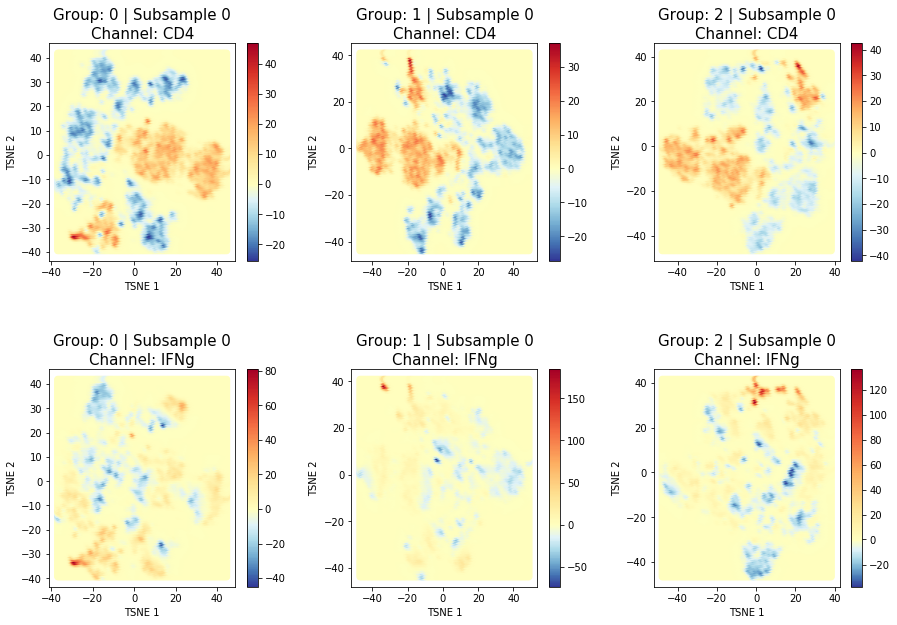

In [31]:
fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(15, 10))
plt.subplots_adjust(wspace = 0.3, hspace = 0.5)
wrap = wrap_img


label = wrap.unique_label()
index = [wrap_img.get_index(label = idx)[0] for idx in label]

for idx, lab in enumerate(label):
    ax = axes[0, idx]
    k = index[idx] #
    p = 5          # CD4
    cax = wrap_img.plot_img(ax, k = k, p = p, cmap = "RdYlBu_r", norm=MidpointNormalize(midpoint=0.)) 
    plt.colorbar(cax, ax = ax)
    
    ax.set_xlabel("TSNE 1")
    ax.set_ylabel("TSNE 2")
    ax.set_title("Group: " + str(lab) + " | Subsample 0" + "\nChannel: CD4", fontsize=15)
    
    
    ax = axes[1, idx]
    k = index[idx]  #
    p = 12          # IFNg
    cax = wrap_img.plot_img(ax, k = k, p = p, cmap = "RdYlBu_r", norm=MidpointNormalize(midpoint=0.)) 
    plt.colorbar(cax, ax = ax)
    
    ax.set_xlabel("TSNE 1")
    ax.set_ylabel("TSNE 2")
    ax.set_title("Group: " + str(lab) + " | Subsample 0" + "\nChannel: IFNg", fontsize=15)
    
plt.savefig(os.path.join(FIG_DIR, "eqapol_pipe01_ksmooth.png"), dpi=300)

**visualization**

In [5]:
idx1 = wrap_tsne.which_label(0)[:3]
idx2 = wrap_tsne.which_label(1)[:3]
idx3 = wrap_tsne.which_label(2)[:3]
indices = np.concatenate([idx1, idx2, idx3])
indices

array([  0,   1,   2, 110, 111, 112, 220, 221, 222])

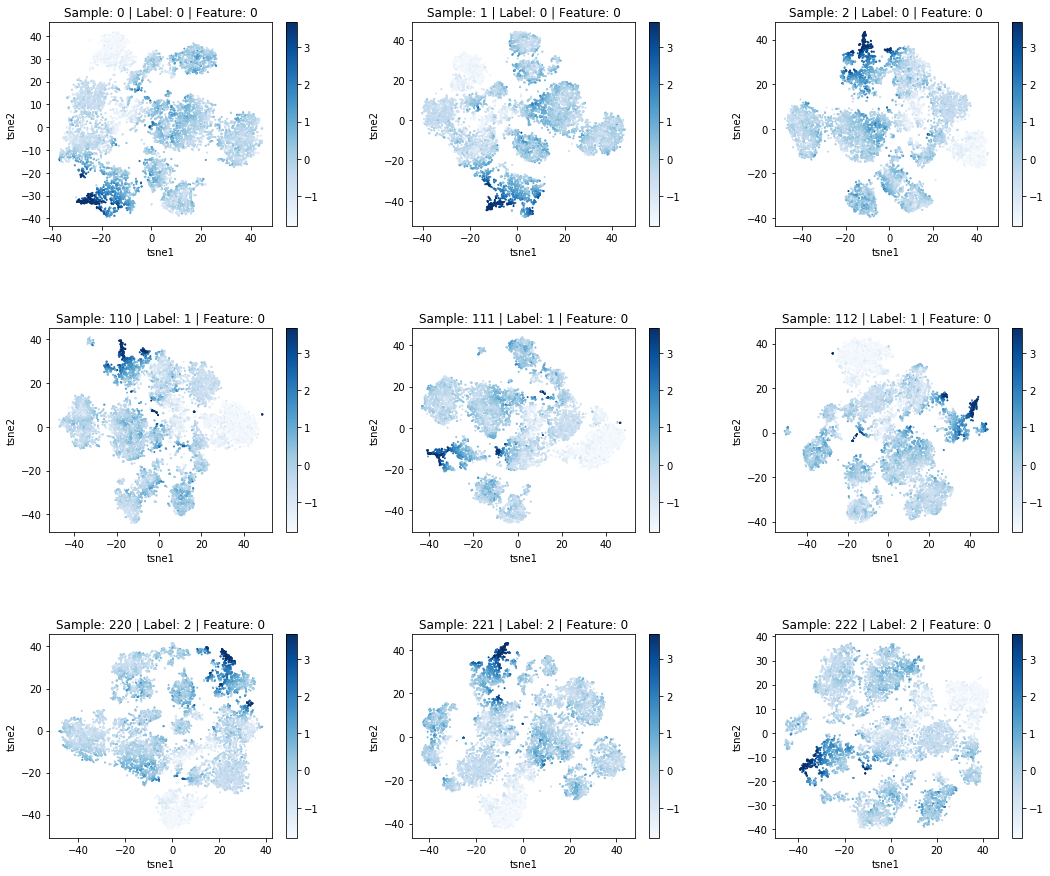

In [6]:
fig, axes = plt.subplots(ncols=3, nrows=3, figsize=(6*3, 5*3))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
axes = axes.ravel()

for idx in range(9):
    ax = axes[idx]
    cax = wrap_tsne.plot_coord(ax, k=indices[idx], p = 0, s = 1, cmap = "Blues")
    ax.set_xlabel("tsne1"); ax.set_ylabel("tsne2")
    fig.colorbar(cax, ax=ax)
pass

# Kernel Smoothing

In [7]:
%%time
density = Transform_Density(sig2 = 1)
wrap_img_var01 = density.transform(wrap_tsne, verbose = True)

Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample: 85
Sample: 86
Sample: 87
Sample: 88
Sample: 89
Sample: 90
Sample: 9

In [8]:
%%time
density = Transform_Density(sig2 = 2)
wrap_img_var02 = density.transform(wrap_tsne, verbose = True)

Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample: 85
Sample: 86
Sample: 87
Sample: 88
Sample: 89
Sample: 90
Sample: 9

In [9]:
%%time
density = Transform_Density(sig2 = 5)
wrap_img_var05 = density.transform(wrap_tsne, verbose = True)

Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample: 85
Sample: 86
Sample: 87
Sample: 88
Sample: 89
Sample: 90
Sample: 9

In [14]:
%%time
density = Transform_Density(sig2 = 10)
wrap_img_var10 = density.transform(wrap_tsne, verbose = True)

Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample: 85
Sample: 86
Sample: 87
Sample: 88
Sample: 89
Sample: 90
Sample: 9

# Store the results

In [10]:
### set up a pickle file
fname = "wrap05_img_1e4_var01.P"
fpath = os.path.join(DAT_DIR, fname)
file = open(fpath, 'wb')

### store the dictionary
pickle.dump(wrap_img_var01, file)
file.close()

In [11]:
### set up a pickle file
fname = "wrap05_img_1e4_var02.P"
fpath = os.path.join(DAT_DIR, fname)
file = open(fpath, 'wb')

### store the dictionary
pickle.dump(wrap_img_var02, file)
file.close()

In [12]:
### set up a pickle file
fname = "wrap05_img_1e4_var05.P"
fpath = os.path.join(DAT_DIR, fname)
file = open(fpath, 'wb')

### store the dictionary
pickle.dump(wrap_img_var05, file)
file.close()

In [15]:
### set up a pickle file
fname = "wrap05_img_1e4_var10.P"
fpath = os.path.join(DAT_DIR, fname)
file = open(fpath, 'wb')

### store the dictionary
pickle.dump(wrap_img_var10, file)
file.close()

In [16]:
!ls /data/clintko/flow_EQAPOL_normal/pipe01

wrap01_data.P		wrap03_subs_1e4_N10.P	wrap05_img_1e4_var02.P
wrap02_scaled_k0.P	wrap04_tsne_1e4_N10.P	wrap05_img_1e4_var05.P
wrap03_subs_1e4_N100.P	wrap05_img_1e4_var01.P	wrap05_img_1e4_var10.P
